In [2]:
# 1. Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv('/content/BostonHousing.csv')

In [4]:
df.head(5)

,Crime_rate,zn,indus,chas,nox,rm,Age,Distance,rad,tax,ptratio,b,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


In [5]:
df.isna().sum()

,0
Crime_rate,0
zn,0
indus,0
chas,0
nox,0
rm,5
Age,0
Distance,0
rad,0
tax,0


In [6]:
df['rm'] = df['rm'].fillna(df['rm'].mean())


In [7]:
df.isna().sum()

,0
Crime_rate,0
zn,0
indus,0
chas,0
nox,0
rm,0
Age,0
Distance,0
rad,0
tax,0


In [8]:

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [9]:
X = df.drop('medv', axis=1)
y = df['medv']

In [10]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [11]:
scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [12]:
model = Sequential([
    Dense(64, activation='relu'),
    Dense(1)   # Output layer
])

In [13]:
model.compile(optimizer='adam', loss='mae')

In [14]:
model.fit(X_train, y_train, epochs=50)

Epoch 1/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 21.8806
Epoch 2/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 21.3806 
Epoch 3/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 20.7703 
Epoch 4/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 19.9922 
Epoch 5/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 19.0274 
Epoch 6/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 17.8919 
Epoch 7/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 16.6359 
Epoch 8/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 15.2970 
Epoch 9/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 13.9625 
Epoch 10/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 12.7367 
Epoch 11/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 11.6432 
Epoch 12/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 10.7701 
Epoch 13/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 10.0332 
Epoch 14/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 9.5047  
Epoch 15/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss:

In [15]:
loss = model.evaluate(X_test, y_test)
print("MAE:", loss)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 4.0125 
MAE: 4.01253080368042


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step


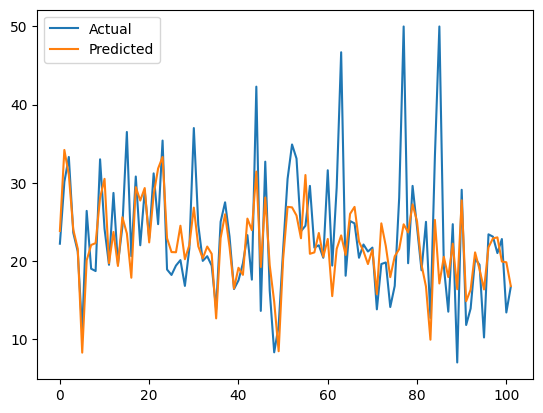

In [16]:
y_pred = model.predict(X_test)

# 12. Plot
plt.plot(y_test.values, label='Actual')
plt.plot(y_pred, label='Predicted')
plt.legend()
plt.show()